# Differentiable Simulation — Gradient Through Physics

SeapoPym simulations are **end-to-end differentiable**. Because the entire pipeline — from parameter input to simulation output — is built on JAX, we can compute exact gradients of any scalar loss with respect to model parameters using `jax.value_and_grad`.

This means: **backpropagation through a physics simulation**, natively.

This example demonstrates:
1. A **twin experiment** — simulate with known parameters, add noise, then recover them
2. **`jax.value_and_grad`** — computing gradients through `jax.lax.scan`
3. **Gradient landscape** — visualizing the loss surface
4. **Gradient descent with Adam** — converging to the true parameters

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import xarray as xr

import seapopym.functions.lotka_volterra  # noqa: F401 — register LV functions
from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import build_step_fn, run
from seapopym.models import LOTKA_VOLTERRA

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. Model Setup

We use the built-in Lotka-Volterra blueprint from SeapoPym's model catalog. The model and its `@functional` physics functions are defined in [the previous example](../01_lotka_volterra/).

## 2. Twin Experiment

We simulate with **known "true" parameters**, then add 5% Gaussian noise to create synthetic observations. The goal: recover the true parameters using only the noisy observations and gradient descent.

This is the standard approach for testing inverse methods in geophysics and climate science.

In [2]:
DAY = 86400.0  # seconds per day

# True parameters (hidden from the optimizer)
TRUE_PARAMS = {
    "alpha": 0.04 / DAY,     # prey growth
    "beta": 0.005 / DAY,     # predation rate
    "delta": 0.5,             # conversion efficiency
    "gamma": 0.1 / DAY,      # predator mortality
}

config = Config.from_dict({
    "parameters": {k: xr.DataArray(v) for k, v in TRUE_PARAMS.items()},
    "forcings": {},
    "initial_state": {
        "prey": xr.DataArray(np.array([[42.0]]), dims=["Y", "X"]),
        "predator": xr.DataArray(np.array([[7.0]]), dims=["Y", "X"]),
    },
    "execution": {"time_start": "2000-01-01", "time_end": "2000-06-30", "dt": "1d"},
})

# Compile and generate "truth"
model = compile_model(LOTKA_VOLTERRA, config)
step_fn = build_step_fn(model, export_variables=["prey", "predator"])
_, truth = run(step_fn, model, model.state, model.parameters, chunk_size=None)

# Add 5% Gaussian noise to prey only (partial observations)
key = jax.random.PRNGKey(42)
obs_prey = truth["prey"] + 0.05 * truth["prey"] * jax.random.normal(key, truth["prey"].shape)

print(f"Generated {truth['prey'].shape[0]} days of observations")
print(f"Prey range: [{float(truth['prey'].min()):.1f}, {float(truth['prey'].max()):.1f}]")

Generated 181 days of observations
Prey range: [34.9, 45.0]


## 3. Computing Gradients

This is where JAX shines. `jax.value_and_grad` differentiates the **entire simulation** — every timestep of `jax.lax.scan` — with respect to the input parameters.

```
parameters ──→ run() ──→ [jax.lax.scan over T timesteps] ──→ outputs ──→ loss
     ↑                                                                      │
     └─────────────────────── jax.grad ────────────────────────────────────┘
```

In [3]:
def loss_fn(params):
    """MSE between simulated prey and noisy observations."""
    _, outputs = run(step_fn, model, model.state, params, chunk_size=None)
    return jnp.mean((outputs["prey"] - obs_prey) ** 2)

# JIT-compile the gradient function
value_and_grad_fn = jax.jit(jax.value_and_grad(loss_fn))

# Compute loss and gradients at the true parameters
loss_val, grads = value_and_grad_fn(model.parameters)

print(f"Loss at true params: {float(loss_val):.4f}  (residual noise)")
print(f"\nGradients (∂ loss / ∂ param):")
for k, v in grads.items():
    print(f"  {k:>8s}: {float(v):+.4e}")

Loss at true params: 3.2811  (residual noise)

Gradients (∂ loss / ∂ param):
     alpha: -5.2836e+06
      beta: +2.5111e+08
     delta: +1.8183e+01
     gamma: -4.6210e+06


## 4. Gradient Landscape

We evaluate the loss on a 2D grid of `alpha` × `gamma` values (keeping `beta` and `delta` fixed at truth). This reveals the optimization landscape that gradient descent navigates.

In [4]:
n_grid = 25
alpha_range = np.linspace(0.02 / DAY, 0.06 / DAY, n_grid)
gamma_range = np.linspace(0.05 / DAY, 0.15 / DAY, n_grid)

loss_grid = np.zeros((n_grid, n_grid))
for i, a in enumerate(alpha_range):
    for j, g in enumerate(gamma_range):
        params = {**model.parameters, "alpha": jnp.array(a), "gamma": jnp.array(g)}
        loss_grid[j, i] = float(loss_fn(params))

print(f"Loss grid: {n_grid}×{n_grid} = {n_grid**2} evaluations")

Loss grid: 25×25 = 625 evaluations


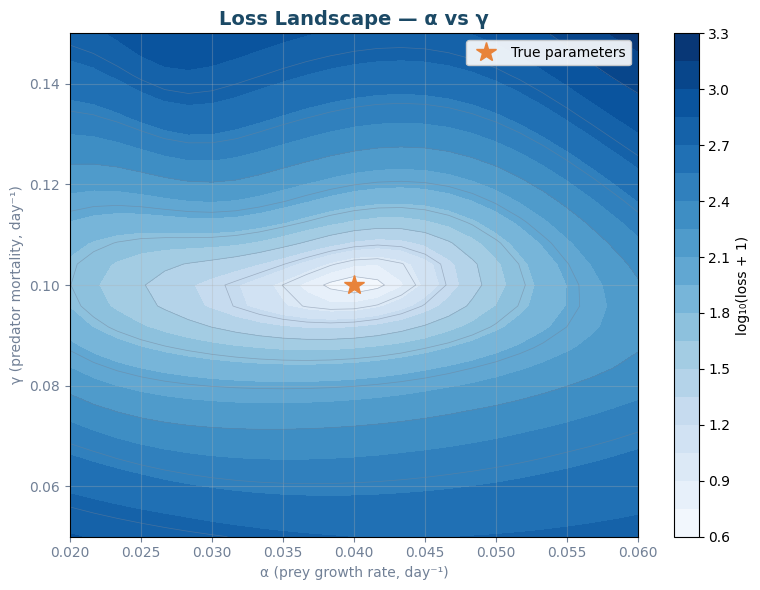

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
alpha_daily = alpha_range * DAY
gamma_daily = gamma_range * DAY

im = ax.contourf(alpha_daily, gamma_daily, np.log10(loss_grid + 1), levels=20, cmap="Blues")
ax.contour(alpha_daily, gamma_daily, np.log10(loss_grid + 1), levels=10, colors="#718096", linewidths=0.5, alpha=0.5)
ax.plot(TRUE_PARAMS["alpha"] * DAY, TRUE_PARAMS["gamma"] * DAY, "*",
        color=PALETTE[2], markersize=15, zorder=5, label="True parameters")
plt.colorbar(im, ax=ax, label="log₁₀(loss + 1)")
ax.set_xlabel("α (prey growth rate, day⁻¹)", color="#718096")
ax.set_ylabel("γ (predator mortality, day⁻¹)", color="#718096")
ax.set_title("Loss Landscape — α vs γ", color="#1B4965", fontsize=14, fontweight="bold")
ax.legend(framealpha=0.9)
ax.tick_params(colors="#718096")
plt.tight_layout()
plt.show()

## 5. Gradient Descent with Adam

We optimize **alpha** (prey growth) and **gamma** (predator mortality) using [Adam](https://arxiv.org/abs/1412.6980) via Optax — the two parameters shown in the landscape above. Beta and delta are held fixed.

Parameters are normalized to [0, 1] based on physical bounds for stable optimization.

Each step:
1. **Forward pass** — run the full simulation (`jax.lax.scan` over 181 timesteps)
2. **Backward pass** — `jax.grad` differentiates through every timestep
3. **Update** — Adam adjusts parameters using adaptive learning rates

In [6]:
import time

# Optimize alpha and gamma only (the two landscape axes)
opt_keys = ["alpha", "gamma"]
bounds = {k: (TRUE_PARAMS[k] * 0.5, TRUE_PARAMS[k] * 2.0) for k in opt_keys}

def to_real(norm_params):
    return {**model.parameters, **{k: jnp.array(bounds[k][0] + norm_params[k] * (bounds[k][1] - bounds[k][0])) for k in norm_params}}

def to_norm(real_params):
    return {k: jnp.array((real_params[k] - bounds[k][0]) / (bounds[k][1] - bounds[k][0])) for k in opt_keys}

def loss_normalized(norm_params):
    return loss_fn(to_real(norm_params))

value_and_grad_norm = jax.jit(jax.value_and_grad(loss_normalized))

# Initial guess: +30% perturbation from truth
init_guess = {k: jnp.array(TRUE_PARAMS[k] * 1.3) for k in opt_keys}
norm_params = to_norm(init_guess)

# Adam optimizer
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(norm_params)

n_steps = 200
history = {"loss": [], "alpha": [], "gamma": []}

t0 = time.perf_counter()
for step in range(n_steps):
    loss_val, grads = value_and_grad_norm(norm_params)
    updates, opt_state = optimizer.update(grads, opt_state, norm_params)
    norm_params = optax.apply_updates(norm_params, updates)
    norm_params = {k: jnp.clip(v, 0.01, 0.99) for k, v in norm_params.items()}

    real = to_real(norm_params)
    history["loss"].append(float(loss_val))
    history["alpha"].append(float(real["alpha"]))
    history["gamma"].append(float(real["gamma"]))

    if step % 50 == 0 or step == n_steps - 1:
        print(f"Step {step:3d} | Loss: {float(loss_val):.4f}")

elapsed = time.perf_counter() - t0
print(f"\n{n_steps} forward+backward passes in {elapsed:.1f}s")

print(f"\nRecovered vs True parameters:")
for k in opt_keys:
    err = abs(history[k][-1] - TRUE_PARAMS[k]) / TRUE_PARAMS[k] * 100
    print(f"  {k:>8s}: recovered = {history[k][-1]:.6e}, true = {TRUE_PARAMS[k]:.6e}, error = {err:.2f}%")

Step   0 | Loss: 320.3634
Step  50 | Loss: 3.7714
Step 100 | Loss: 3.2757
Step 150 | Loss: 3.2723
Step 199 | Loss: 3.2723

200 forward+backward passes in 0.3s

Recovered vs True parameters:
     alpha: recovered = 4.647185e-07, true = 4.629630e-07, error = 0.38%
     gamma: recovered = 1.159207e-06, true = 1.157407e-06, error = 0.16%


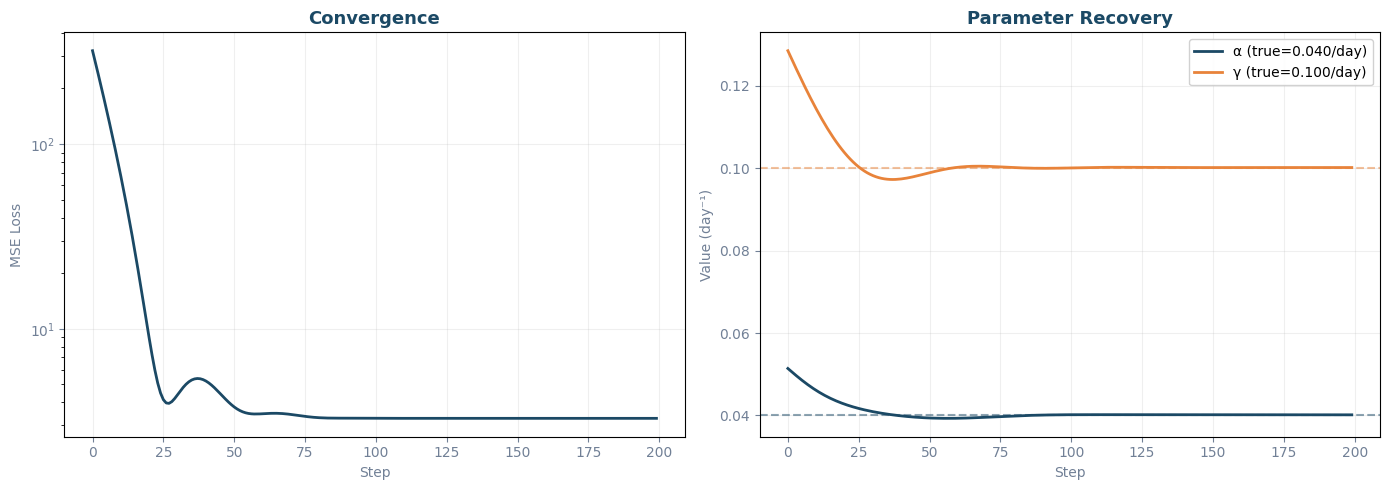

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax = axes[0]
ax.semilogy(history["loss"], color=PALETTE[0], linewidth=2)
ax.set_xlabel("Step", color="#718096")
ax.set_ylabel("MSE Loss", color="#718096")
ax.set_title("Convergence", color="#1B4965", fontsize=13, fontweight="bold")
ax.tick_params(colors="#718096")
ax.grid(True, alpha=0.2)

# Parameter convergence
ax = axes[1]
for k, color, label in [("alpha", PALETTE[0], "\u03b1"), ("gamma", PALETTE[2], "\u03b3")]:
    true_val = TRUE_PARAMS[k] * DAY
    recovered = np.array(history[k]) * DAY
    ax.plot(recovered, color=color, linewidth=2, label=f"{label} (true={true_val:.3f}/day)")
    ax.axhline(true_val, color=color, linestyle="--", alpha=0.5)
ax.set_xlabel("Step", color="#718096")
ax.set_ylabel("Value (day\u207b\u00b9)", color="#718096")
ax.set_title("Parameter Recovery", color="#1B4965", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
ax.tick_params(colors="#718096")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

### Optimization Trajectory on Loss Landscape

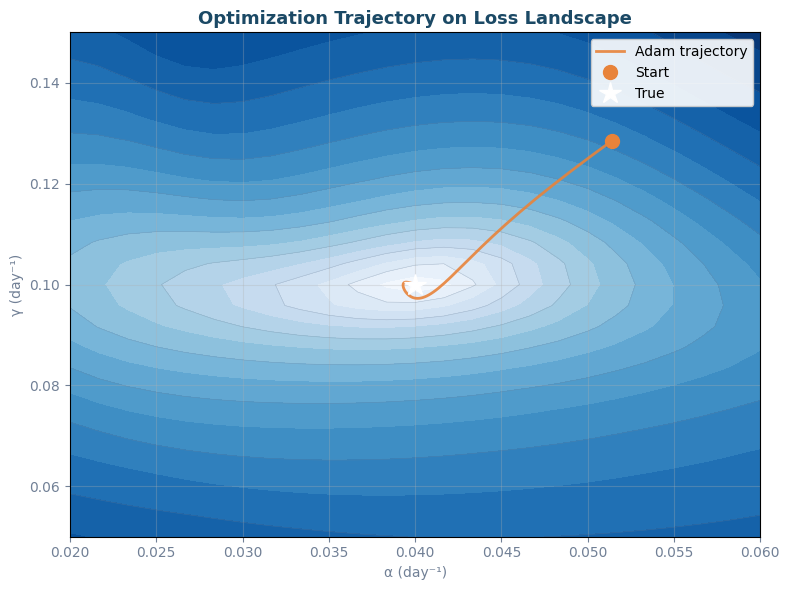

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(alpha_daily, gamma_daily, np.log10(loss_grid + 1), levels=20, cmap="Blues")
ax.contour(alpha_daily, gamma_daily, np.log10(loss_grid + 1), levels=8, colors="#718096", linewidths=0.4, alpha=0.4)

# Optimization trajectory
traj_alpha = np.array(history["alpha"]) * DAY
traj_gamma = np.array(history["gamma"]) * DAY
ax.plot(traj_alpha, traj_gamma, "-", color=PALETTE[2], linewidth=2, alpha=0.9, label="Adam trajectory")
ax.plot(traj_alpha[0], traj_gamma[0], "o", color=PALETTE[2], markersize=10, zorder=5, label="Start")
ax.plot(TRUE_PARAMS["alpha"] * DAY, TRUE_PARAMS["gamma"] * DAY, "*", color="white", markersize=16, zorder=5, label="True")

ax.set_xlabel("\u03b1 (day\u207b\u00b9)", color="#718096")
ax.set_ylabel("\u03b3 (day\u207b\u00b9)", color="#718096")
ax.set_title("Optimization Trajectory on Loss Landscape", color="#1B4965", fontsize=13, fontweight="bold")
ax.legend(framealpha=0.9)
ax.tick_params(colors="#718096")
plt.tight_layout()
plt.show()

## Summary

| What | How |
|------|-----|
| Forward simulation | `run()` — `jax.lax.scan` over 181 timesteps |
| Backward pass | `jax.value_and_grad(loss_fn)` — exact gradients through the full simulation |
| Optimization | Adam (Optax) — 200 steps, <1% parameter error on α and γ |

The key insight: because SeapoPym's simulation loop is a **pure JAX function**, automatic differentiation works out of the box. No adjoint code, no finite differences, no approximations — just `jax.grad`.

This enables gradient-based calibration, sensitivity analysis, and integration with any JAX-compatible ML pipeline.

**Next**: [Optimization Strategies](../03_optimization/) — comparing gradient descent, CMA-ES, and genetic algorithms on a marine ecosystem model.